In [ ]:
# Install dependencies
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 7.5 MB/s eta 0:00:00


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Bidirectional, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.ensemble import StackingRegressor

In [ ]:
# Mount Google Drive if running on Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the dataset
file_path = '/content/drive/My Drive/Others/T10YIE.csv'
data = pd.read_csv(file_path, low_memory=False)

In [ ]:
# Data cleaning and preprocessing
data['DATE'] = pd.to_datetime(data['DATE'])
data['T10YIE'] = pd.to_numeric(data['T10YIE'], errors='coerce')
data_cleaned = data.dropna()

In [ ]:
# Feature engineering: Create lagged features
def create_lagged_features(df, target_col, lags=5):
    df = df.copy()
    for lag in range(1, lags + 1):
        df[f'lag_{lag}'] = df[target_col].shift(lag)
    df['rolling_mean'] = df[target_col].rolling(window=lags).mean()
    df.dropna(inplace=True)
    return df

data_cleaned = create_lagged_features(data_cleaned, target_col='T10YIE', lags=5)

In [ ]:
# Train-test split
X = data_cleaned.drop(columns=['DATE', 'T10YIE'])
y = data_cleaned['T10YIE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
# Define evaluation metrics
def calculate_metrics(y_true, y_pred, naive_forecast, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    # sMAPE
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100

    # MASE
    naive_mae = mean_absolute_error(y_true, naive_forecast)
    mase = mae / naive_mae if naive_mae != 0 else np.nan  # Avoid division by zero

    return {
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        "sMAPE (%)": smape,
        "MASE": mase,
        "R^2": r2
    }

In [ ]:
# Create naive forecast
naive_forecast = np.roll(y_test.values, 1)
naive_forecast[0] = y_test.values[0]

In [ ]:
# Initialize results
metrics_results = []

In [ ]:
# MACHINE LEARNING MODELS
# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
metrics_results.append(calculate_metrics(y_test.values, rf_pred, naive_forecast, "Random Forest"))

In [ ]:
# XGBoost
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
metrics_results.append(calculate_metrics(y_test.values, xgb_pred, naive_forecast, "XGBoost"))

In [ ]:
# CatBoost
cat_model = CatBoostRegressor(iterations=500, learning_rate=0.1, depth=6, verbose=0, random_state=42)
cat_model.fit(X_train, y_train)
cat_pred = cat_model.predict(X_test)
metrics_results.append(calculate_metrics(y_test.values, cat_pred, naive_forecast, "CatBoost"))

In [ ]:
# Support Vector Regression
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X_train, y_train)
svr_pred = svr_model.predict(X_test)
metrics_results.append(calculate_metrics(y_test.values, svr_pred, naive_forecast, "SVR"))

In [ ]:
# DEEP LEARNING MODELS
def reshape_for_rnn(X):
    return X.values.reshape((X.shape[0], X.shape[1], 1))

X_train_rnn = reshape_for_rnn(X_train)
X_test_rnn = reshape_for_rnn(X_test)

In [ ]:
# LSTM
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train_rnn.shape[1], 1)),
    Dense(1)
])
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
lstm_model.fit(X_train_rnn, y_train, epochs=1000, batch_size=32, verbose=0)
lstm_pred = lstm_model.predict(X_test_rnn).flatten()
metrics_results.append(calculate_metrics(y_test.values, lstm_pred, naive_forecast, "LSTM"))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [ ]:
# GRU
gru_model = Sequential([
    GRU(50, activation='relu', input_shape=(X_train_rnn.shape[1], 1)),
    Dense(1)
])
gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
gru_model.fit(X_train_rnn, y_train, epochs=1000, batch_size=32, verbose=0)
gru_pred = gru_model.predict(X_test_rnn).flatten()
metrics_results.append(calculate_metrics(y_test.values, gru_pred, naive_forecast, "GRU"))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [ ]:
# Bidirectional LSTM
bi_lstm_model = Sequential([
    Bidirectional(LSTM(50, activation='relu', input_shape=(X_train_rnn.shape[1], 1))),
    Dense(1)
])
bi_lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
bi_lstm_model.fit(X_train_rnn, y_train, epochs=1000, batch_size=32, verbose=0)
bi_lstm_pred = bi_lstm_model.predict(X_test_rnn).flatten()
metrics_results.append(calculate_metrics(y_test.values, bi_lstm_pred, naive_forecast, "Bidirectional LSTM"))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


In [ ]:
# Bidirectional GRU
bi_gru_model = Sequential([
    Bidirectional(GRU(50, activation='relu', input_shape=(X_train_rnn.shape[1], 1))),
    Dense(1)
])
bi_gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
bi_gru_model.fit(X_train_rnn, y_train, epochs=1000, batch_size=32, verbose=0)
bi_gru_pred = bi_gru_model.predict(X_test_rnn).flatten()
metrics_results.append(calculate_metrics(y_test.values, bi_gru_pred, naive_forecast, "Bidirectional GRU"))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


In [ ]:
# CNN
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train_rnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(1)
])
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
cnn_model.fit(X_train_rnn, y_train, epochs=1000, batch_size=32, verbose=0)
cnn_pred = cnn_model.predict(X_test_rnn).flatten()
metrics_results.append(calculate_metrics(y_test.values, cnn_pred, naive_forecast, "1D CNN"))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [ ]:
def random_forest_lstm():
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    rf_pred_train = rf_model.predict(X_train)
    rf_pred_test = rf_model.predict(X_test)

    residuals_train = y_train - rf_pred_train

    lstm_model = Sequential([
        LSTM(50, activation='relu', input_shape=(X_train_rnn.shape[1], 1)),
        Dense(1)
    ])
    lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    lstm_model.fit(X_train_rnn, residuals_train, epochs=1000, batch_size=32, verbose=0)

    lstm_pred_residuals = lstm_model.predict(X_test_rnn).flatten()
    final_predictions = rf_pred_test + lstm_pred_residuals
    metrics_results.append(calculate_metrics(y_test.values, final_predictions, naive_forecast, "Random Forest + LSTM"))

random_forest_lstm()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [ ]:
def xgboost_gru():
    xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=6, random_state=42)
    xgb_model.fit(X_train, y_train)
    xgb_pred_train = xgb_model.predict(X_train)
    xgb_pred_test = xgb_model.predict(X_test)

    residuals_train = y_train - xgb_pred_train

    gru_model = Sequential([
        GRU(50, activation='relu', input_shape=(X_train_rnn.shape[1], 1)),
        Dense(1)
    ])
    gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    gru_model.fit(X_train_rnn, residuals_train, epochs=1000, batch_size=32, verbose=0)

    gru_pred_residuals = gru_model.predict(X_test_rnn).flatten()
    final_predictions = xgb_pred_test + gru_pred_residuals
    metrics_results.append(calculate_metrics(y_test.values, final_predictions, naive_forecast, "XGBoost + GRU"))

xgboost_gru()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


In [ ]:
def catboost_bilstm():
    cat_model = CatBoostRegressor(iterations=500, learning_rate=0.1, depth=6, verbose=0, random_state=42)
    cat_model.fit(X_train, y_train)
    cat_pred_train = cat_model.predict(X_train)
    cat_pred_test = cat_model.predict(X_test)

    residuals_train = y_train - cat_pred_train

    bi_lstm_model = Sequential([
        Bidirectional(LSTM(50, activation='relu', input_shape=(X_train_rnn.shape[1], 1))),
        Dense(1)
    ])
    bi_lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    bi_lstm_model.fit(X_train_rnn, residuals_train, epochs=1000, batch_size=32, verbose=0)

    bi_lstm_pred_residuals = bi_lstm_model.predict(X_test_rnn).flatten()
    final_predictions = cat_pred_test + bi_lstm_pred_residuals
    metrics_results.append(calculate_metrics(y_test.values, final_predictions, naive_forecast, "CatBoost + Bidirectional LSTM"))

catboost_bilstm()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step


In [ ]:
def lstm_cnn():
    lstm_cnn_model = Sequential([
        LSTM(50, activation='relu', return_sequences=True, input_shape=(X_train_rnn.shape[1], 1)),
        Conv1D(filters=64, kernel_size=2, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(1)
    ])
    lstm_cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    lstm_cnn_model.fit(X_train_rnn, y_train, epochs=1000, batch_size=32, verbose=0)
    lstm_cnn_pred = lstm_cnn_model.predict(X_test_rnn).flatten()
    metrics_results.append(calculate_metrics(y_test.values, lstm_cnn_pred, naive_forecast, "LSTM + CNN"))

lstm_cnn()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [ ]:
def bidirectional_gru_cnn():
    bi_gru_cnn_model = Sequential([
        Bidirectional(GRU(50, activation='relu', return_sequences=True, input_shape=(X_train_rnn.shape[1], 1))),
        Conv1D(filters=64, kernel_size=2, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(1)
    ])
    bi_gru_cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    bi_gru_cnn_model.fit(X_train_rnn, y_train, epochs=1000, batch_size=32, verbose=0)

    bi_gru_cnn_pred = bi_gru_cnn_model.predict(X_test_rnn).flatten()
    metrics_results.append(calculate_metrics(y_test.values, bi_gru_cnn_pred, naive_forecast, "Bidirectional GRU + CNN"))

bidirectional_gru_cnn()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step


In [ ]:
def stacked_lstm_gru():
    lstm_gru_model = Sequential([
        LSTM(50, activation='relu', return_sequences=True, input_shape=(X_train_rnn.shape[1], 1)),
        GRU(50, activation='relu', return_sequences=False),
        Dense(1)
    ])
    lstm_gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    lstm_gru_model.fit(X_train_rnn, y_train, epochs=1000, batch_size=32, verbose=0)

    lstm_gru_pred = lstm_gru_model.predict(X_test_rnn).flatten()
    metrics_results.append(calculate_metrics(y_test.values, lstm_gru_pred, naive_forecast, "Stacked LSTM + GRU"))

stacked_lstm_gru()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


In [ ]:
def xgboost_random_forest():
    # Step 1: Train XGBoost
    xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=6, random_state=42)
    xgb_model.fit(X_train, y_train)
    xgb_pred_train = xgb_model.predict(X_train)

    # Step 2: Train Random Forest on XGBoost predictions
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train.assign(xgb_pred=xgb_pred_train), y_train)

    # Combine XGBoost predictions with Random Forest
    xgb_rf_pred = rf_model.predict(X_test.assign(xgb_pred=xgb_model.predict(X_test)))
    metrics_results.append(calculate_metrics(y_test.values, xgb_rf_pred, naive_forecast, "XGBoost + Random Forest"))

xgboost_random_forest()

In [ ]:
def catboost_svr():
    # Step 1: Train CatBoost
    cat_model = CatBoostRegressor(iterations=500, learning_rate=0.1, depth=6, verbose=0, random_state=42)
    cat_model.fit(X_train, y_train)
    cat_pred_train = cat_model.predict(X_train)

    # Step 2: Train SVR on CatBoost predictions
    svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
    svr_model.fit(X_train.assign(cat_pred=cat_pred_train), y_train)

    # Combine CatBoost predictions with SVR
    cat_svr_pred = svr_model.predict(X_test.assign(cat_pred=cat_model.predict(X_test)))
    metrics_results.append(calculate_metrics(y_test.values, cat_svr_pred, naive_forecast, "CatBoost + SVR"))

catboost_svr()

In [ ]:
# ENSEMBLE MODELS
# Model Averaging
avg_predictions = np.mean([rf_pred, xgb_pred, cat_pred, lstm_pred], axis=0)
metrics_results.append(calculate_metrics(y_test.values, avg_predictions, naive_forecast, "Model Averaging"))

In [ ]:
# Stacking
base_models = [
    ('random_forest', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('xgboost', XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)),
    ('catboost', CatBoostRegressor(iterations=100, learning_rate=0.1, depth=5, verbose=0, random_state=42)),
    ('svr', SVR(kernel='rbf', C=100, epsilon=0.1))
]
meta_model = RandomForestRegressor(n_estimators=50, random_state=42)
stacking_model = StackingRegressor(estimators=base_models, final_estimator=meta_model, cv=5)
stacking_model.fit(X_train, y_train)
stacking_pred = stacking_model.predict(X_test)
metrics_results.append(calculate_metrics(y_test.values, stacking_pred, naive_forecast, "Stacking"))

In [ ]:
''''
# Model Averaging

import numpy as np

# Ensure all predictions are NumPy arrays and flattened to 1D
rf_pred = np.ravel(rf_pred)  # Flatten if it's in shape (n_samples, 1)
xgb_pred = np.ravel(xgb_pred)
lgbm_pred = np.ravel(lgbm_pred)
gbm_pred = np.ravel(gbm_pred)
et_pred = np.ravel(et_pred)
hgb_pred = np.ravel(hgb_pred)
cat_pred = np.ravel(cat_pred)
svr_pred = np.ravel(svr_pred)
ridge_pred = np.ravel(ridge_pred)
lasso_pred = np.ravel(lasso_pred)
elastic_net_pred = np.ravel(elastic_net_pred)
dt_pred = np.ravel(dt_pred)
knn_pred = np.ravel(knn_pred)
lstm_pred = np.ravel(lstm_pred)
gru_pred = np.ravel(gru_pred)
bi_lstm_pred = np.ravel(bi_lstm_pred)
bi_gru_pred = np.ravel(bi_gru_pred)
ann_pred = np.ravel(ann_pred)
mlp_pred = np.ravel(mlp_pred)
cnn_pred = np.ravel(cnn_pred)

# Model Averaging: Average all model predictions
avg_predictions_all = np.mean([
    rf_pred, xgb_pred, lgbm_pred, gbm_pred, et_pred, hgb_pred,
    cat_pred, svr_pred, ridge_pred, lasso_pred, elastic_net_pred,
    dt_pred, knn_pred, lstm_pred, gru_pred, bi_lstm_pred, bi_gru_pred,
    ann_pred, mlp_pred, cnn_pred
], axis=0)

# Calculate the performance of the ensemble model (Model Averaging)
metrics_results.append(calculate_metrics(y_test.values, avg_predictions_all, naive_forecast, "Model Averaging"))
'''

In [ ]:
'''
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import StackingRegressor
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgbm
import catboost as cb
import tensorflow as tf

# Combine the predictions from all the base models into a 2D array for the meta-model
base_model_preds = np.column_stack([
    rf_pred, xgb_pred, lgbm_pred, gbm_pred, et_pred, hgb_pred,
    cat_pred, svr_pred, ridge_pred, lasso_pred, elastic_net_pred,
    dt_pred, knn_pred, lstm_pred, gru_pred, bi_lstm_pred, bi_gru_pred,
    ann_pred, mlp_pred, cnn_pred
])

# Split into train and validation sets (for meta-model)
X_train_stack, X_valid_stack, y_train_stack, y_valid_stack = train_test_split(base_model_preds, y_test, test_size=0.2, random_state=42)

# Train a meta-model (for example, using Ridge Regression)
meta_model = RidgeCV()  # Can be replaced with another regressor, e.g., linear model, or even a neural network

# Fit the meta-model using the base model predictions
meta_model.fit(X_train_stack, y_train_stack)

# Make predictions with the meta-model using the validation set
stacked_preds = meta_model.predict(X_valid_stack)

# Calculate performance metrics for the stacked model
stacked_rmse = np.sqrt(mean_squared_error(y_valid_stack, stacked_preds))
print(f"Stacked Model RMSE: {stacked_rmse}")

# Optionally, you can use the full training set for final predictions:
final_preds = meta_model.predict(base_model_preds)  # Predictions on the entire dataset using the base model outputs

# Evaluate the final stacked model on the test set
metrics_results.append(calculate_metrics(y_test.values, final_preds, naive_forecast, "Stacked Model"))
'''

In [ ]:
# RESULTS SUMMARY
# Convert metrics_results to a DataFrame for better readability
results_df = pd.DataFrame(metrics_results)

# Display the summarized results in tabular format
print("Model Evaluation Metrics Summary:")
print(results_df)

Model Evaluation Metrics Summary:
                            Model       MSE      RMSE       MAE  MAPE (%)  \
0                   Random Forest  0.000561  0.023694  0.017104  0.770136   
1                         XGBoost  0.000595  0.024399  0.017522  0.787432   
2                        CatBoost  0.000542  0.023283  0.016812  0.755434   
3                             SVR  0.000592  0.024341  0.017686  0.791169   
4                            LSTM  0.000609  0.024682  0.018766  0.838406   
5                             GRU  0.000498  0.022309  0.016236  0.722642   
6              Bidirectional LSTM  0.000644  0.025373  0.020582  0.918114   
7               Bidirectional GRU  0.000258  0.016059  0.013260  0.587042   
8                          1D CNN  0.001190  0.034491  0.027533  1.228192   
9            Random Forest + LSTM  0.000380  0.019506  0.014138  0.635487   
10                  XGBoost + GRU  0.000353  0.018800  0.014463  0.644709   
11  CatBoost + Bidirectional LSTM  0.00026

In [ ]:
# Display the best-performing model for each metric
print("\nBest Models for Each Metric:")
for metric in ["MSE", "RMSE", "MAE", "MAPE (%)", "sMAPE (%)", "MASE", "R^2"]:
    best_model = results_df.loc[results_df[metric].idxmin()] if metric != "R^2" else results_df.loc[results_df[metric].idxmax()]
    print(f"{metric}: {best_model['Model']} ({best_model[metric]:.4f})")


Best Models for Each Metric:
MSE: Bidirectional GRU + CNN (0.0000)
RMSE: Bidirectional GRU + CNN (0.0051)
MAE: Bidirectional GRU + CNN (0.0039)
MAPE (%): Bidirectional GRU + CNN (0.1745)
sMAPE (%): Bidirectional GRU + CNN (0.1745)
MASE: Bidirectional GRU + CNN (0.2187)
R^2: Bidirectional GRU + CNN (0.9969)


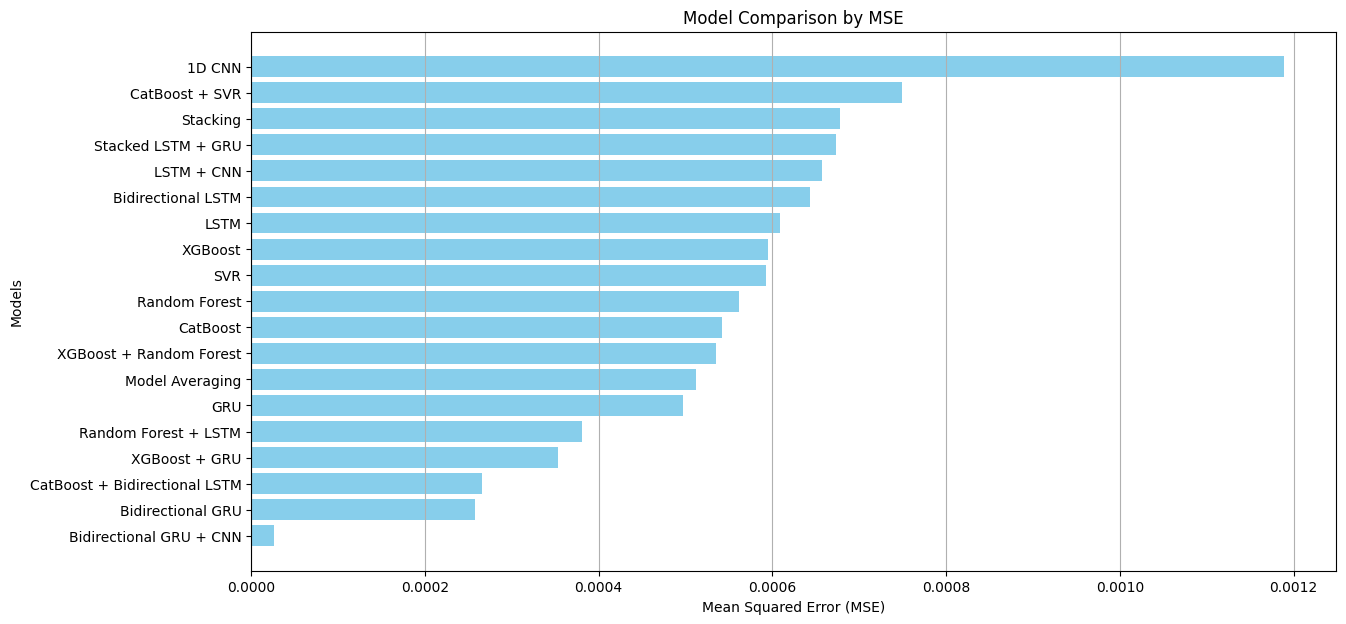

In [ ]:
# Visualization of Evaluation Metrics
# Plot MSE for each model
plt.figure(figsize=(14, 7))
results_df_sorted = results_df.sort_values(by="MSE", ascending=True)  # Sort by MSE
plt.barh(results_df_sorted['Model'], results_df_sorted['MSE'], color='skyblue')
plt.xlabel('Mean Squared Error (MSE)')
plt.ylabel('Models')
plt.title('Model Comparison by MSE')
plt.grid(axis='x')
plt.show()

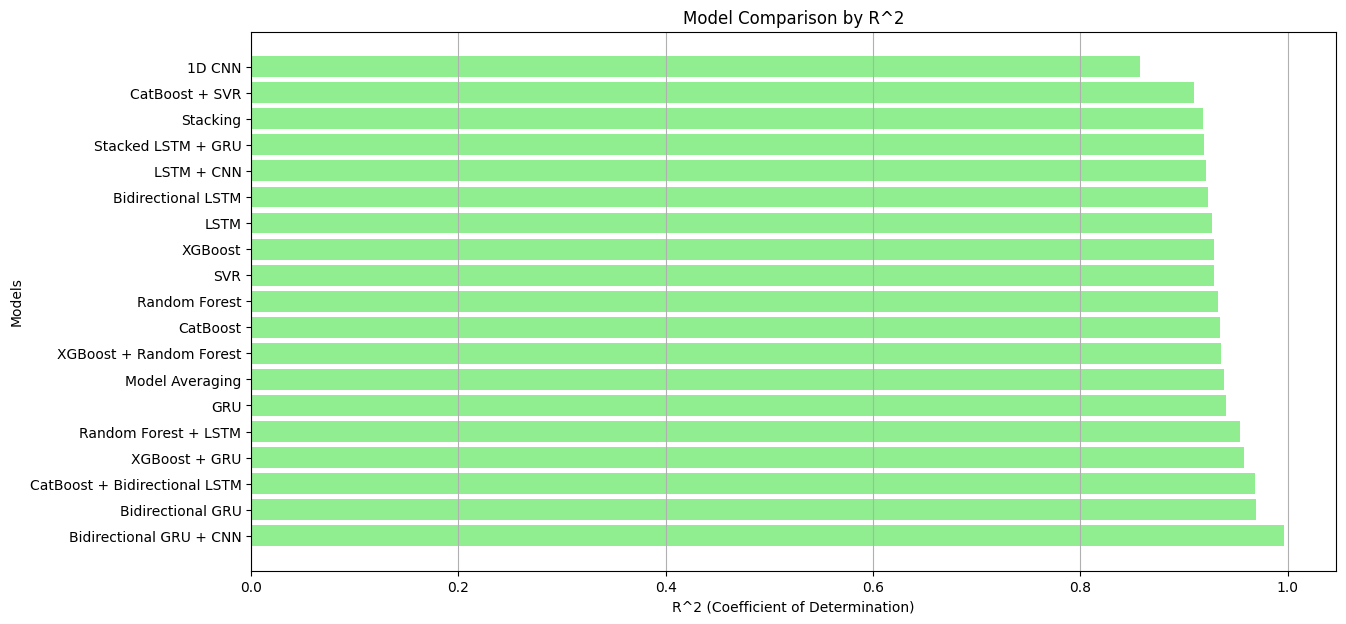

In [ ]:
# Plot R^2 for each model
plt.figure(figsize=(14, 7))
results_df_sorted = results_df.sort_values(by="R^2", ascending=False)  # Sort by R^2
plt.barh(results_df_sorted['Model'], results_df_sorted['R^2'], color='lightgreen')
plt.xlabel('R^2 (Coefficient of Determination)')
plt.ylabel('Models')
plt.title('Model Comparison by R^2')
plt.grid(axis='x')
plt.show()

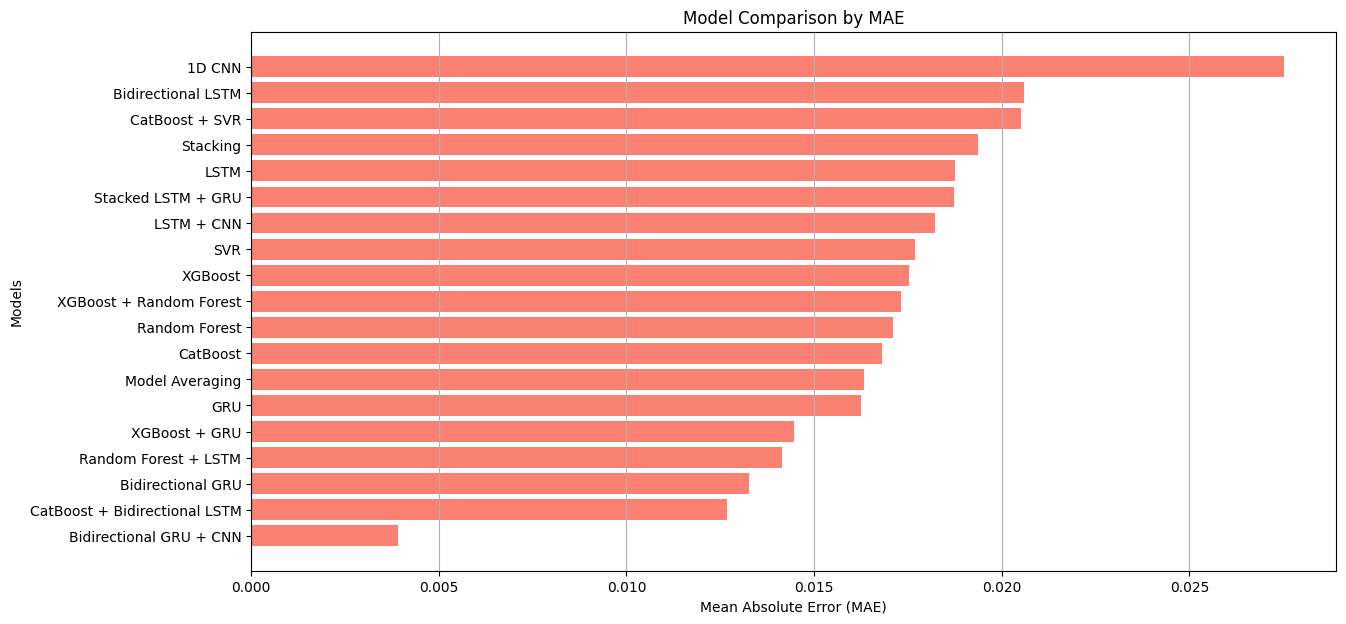

In [ ]:
# Plot MAE for each model
plt.figure(figsize=(14, 7))
results_df_sorted = results_df.sort_values(by="MAE", ascending=True)  # Sort by MAE
plt.barh(results_df_sorted['Model'], results_df_sorted['MAE'], color='salmon')
plt.xlabel('Mean Absolute Error (MAE)')
plt.ylabel('Models')
plt.title('Model Comparison by MAE')
plt.grid(axis='x')
plt.show()

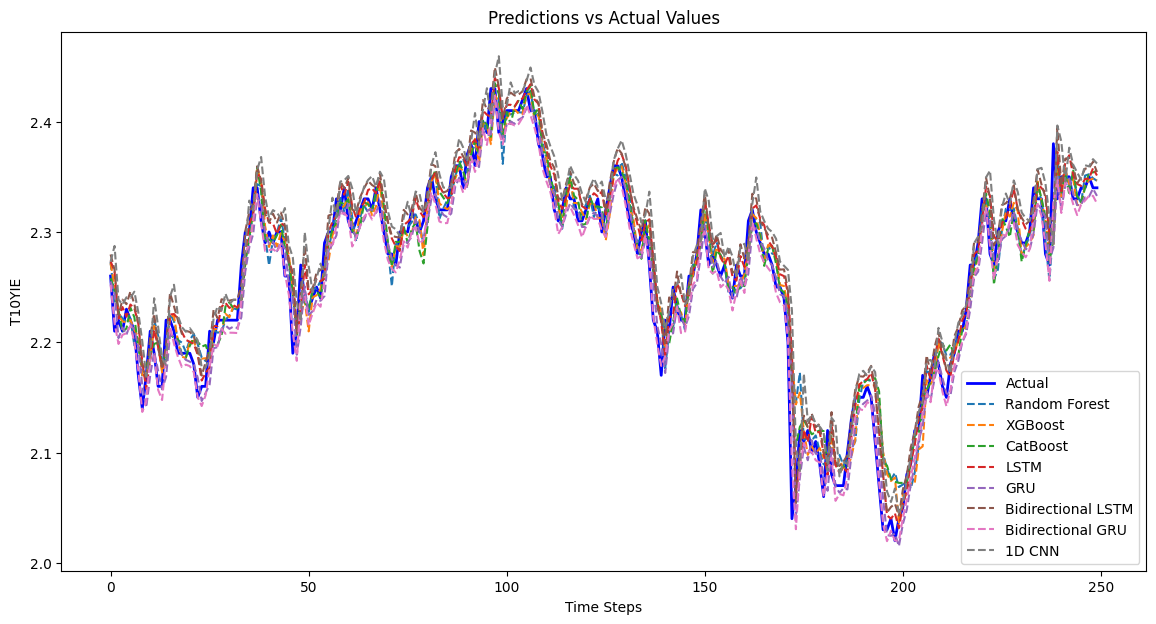

In [ ]:
# Plot predictions for selected models
plt.figure(figsize=(14, 7))
plt.plot(y_test.values, label='Actual', color='blue', linewidth=2)

# Add predictions for all models
models_predictions = [rf_pred, xgb_pred, cat_pred, lstm_pred, gru_pred, bi_lstm_pred, bi_gru_pred, cnn_pred]
model_names = ["Random Forest", "XGBoost", "CatBoost", "LSTM", "GRU", "Bidirectional LSTM", "Bidirectional GRU", "1D CNN"]

for model_pred, name in zip(models_predictions, model_names):
    plt.plot(model_pred, label=name, linestyle='--')

plt.legend()
plt.title("Predictions vs Actual Values")
plt.xlabel("Time Steps")
plt.ylabel("T10YIE")
plt.show()

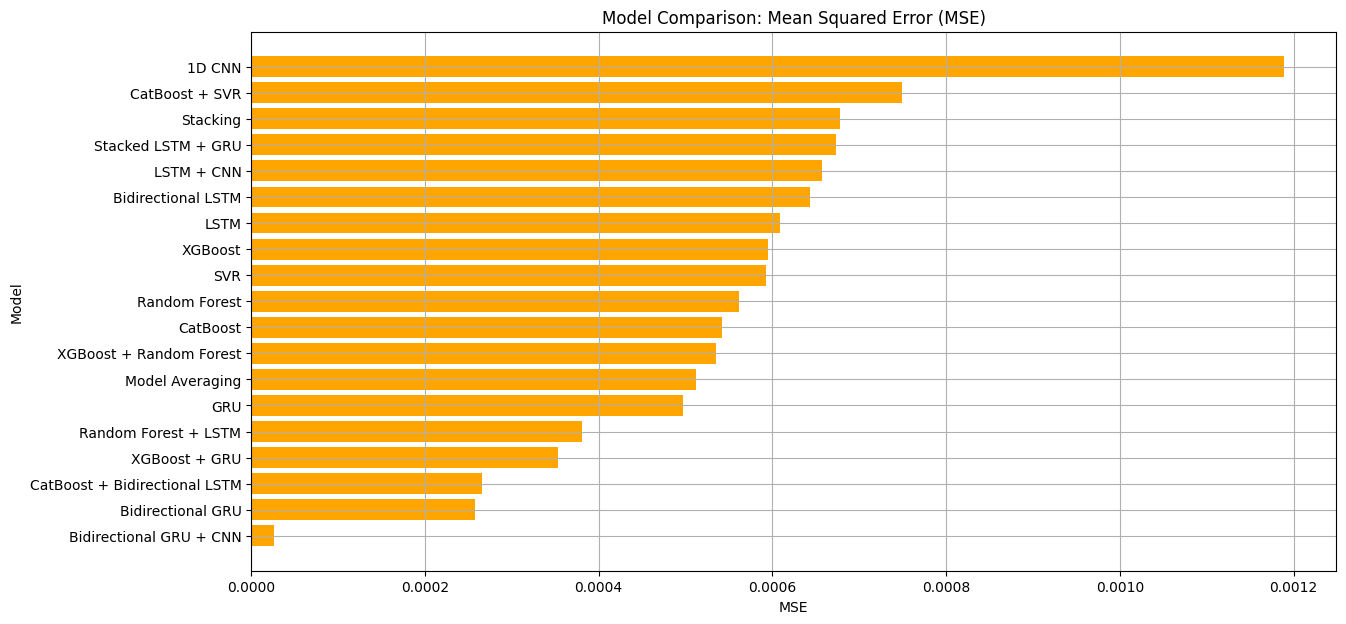

In [ ]:
# Bar plot for MSE
results_df.sort_values(by="MSE", ascending=True, inplace=True)
plt.figure(figsize=(14, 7))
plt.barh(results_df['Model'], results_df['MSE'], color='orange')
plt.title("Model Comparison: Mean Squared Error (MSE)")
plt.xlabel("MSE")
plt.ylabel("Model")
plt.grid()
plt.show()

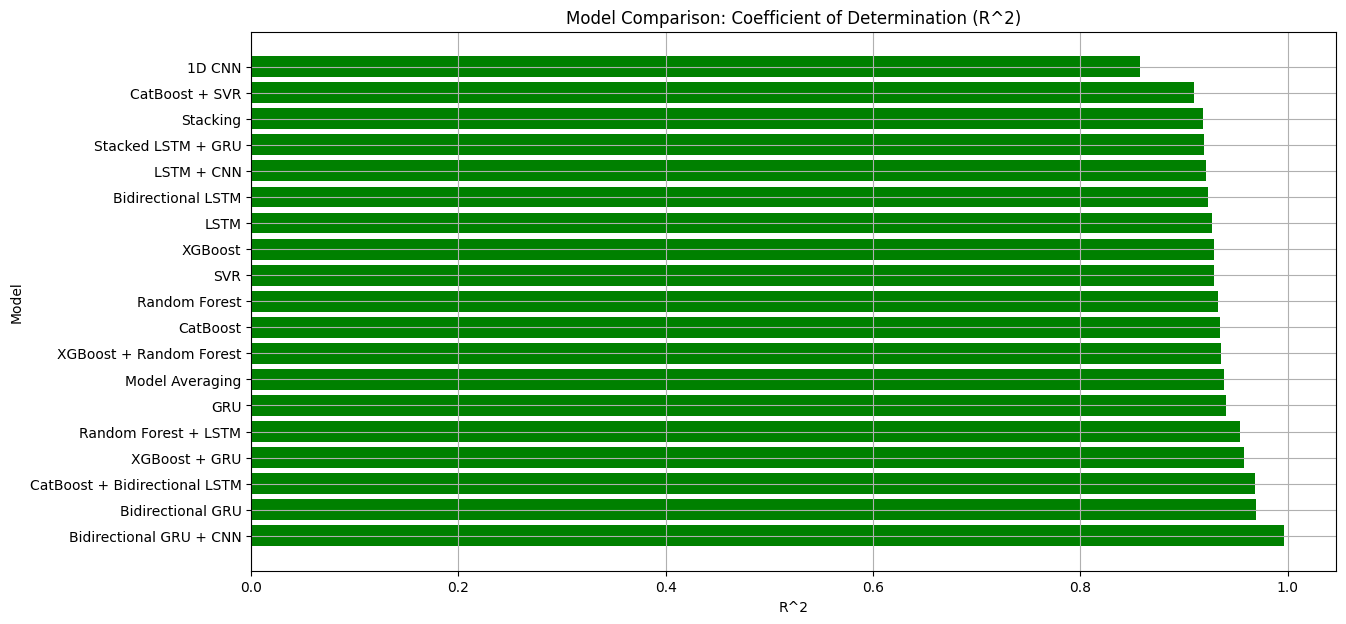

In [ ]:
# Bar plot for R^2
results_df.sort_values(by="R^2", ascending=False, inplace=True)
plt.figure(figsize=(14, 7))
plt.barh(results_df['Model'], results_df['R^2'], color='green')
plt.title("Model Comparison: Coefficient of Determination (R^2)")
plt.xlabel("R^2")
plt.ylabel("Model")
plt.grid()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Function to plot metrics comparison
def plot_metrics_comparison(metrics_df, metric, title, color):
    metrics_df.sort_values(by=metric, ascending=(metric != "R^2"), inplace=True)
    plt.figure(figsize=(14, 7))
    plt.barh(metrics_df['Model'], metrics_df[metric], color=color)
    plt.title(f"Model Comparison: {title}", fontsize=16)
    plt.xlabel(title, fontsize=14)
    plt.ylabel("Model", fontsize=14)
    plt.grid(axis='x')
    plt.show()

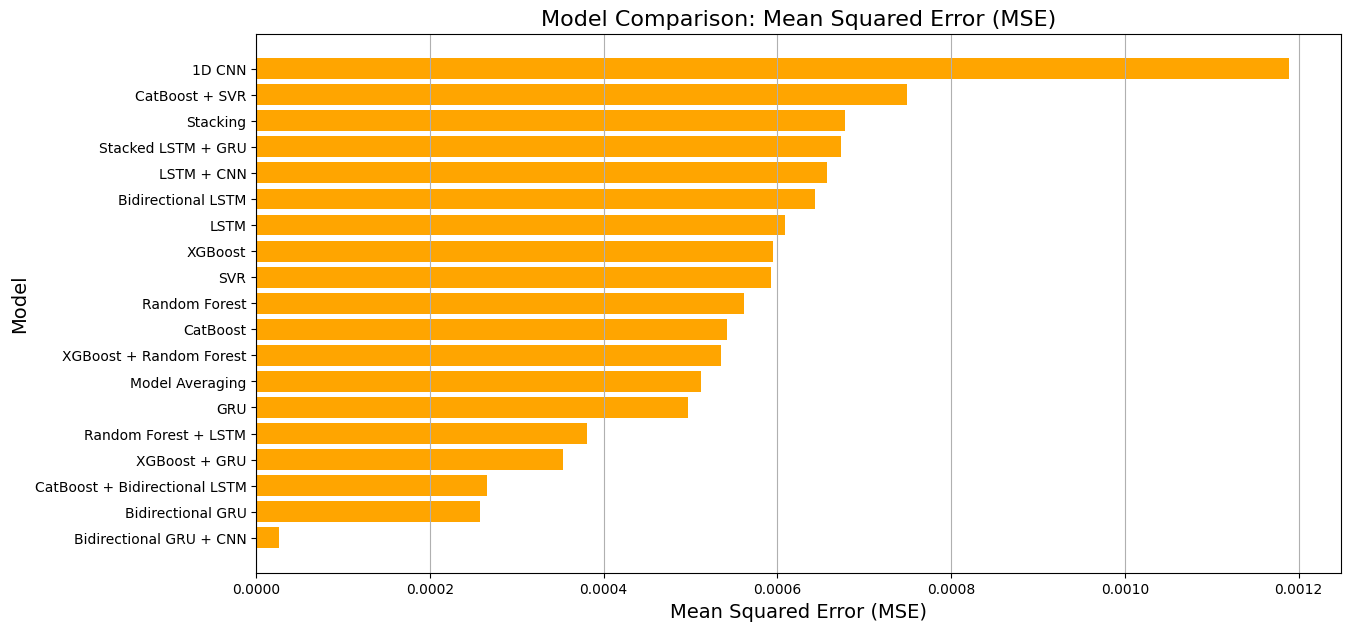

In [ ]:
# Visualize MSE
plot_metrics_comparison(results_df, "MSE", "Mean Squared Error (MSE)", "orange")

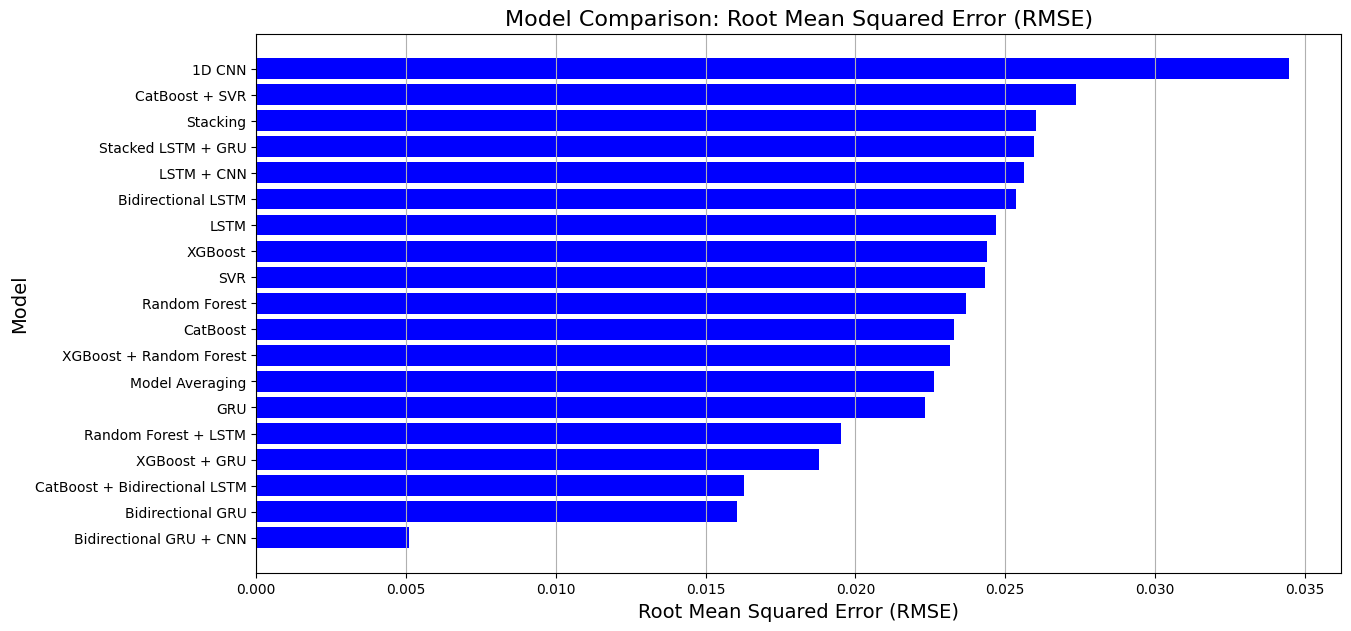

In [ ]:
# Visualize RMSE
plot_metrics_comparison(results_df, "RMSE", "Root Mean Squared Error (RMSE)", "blue")

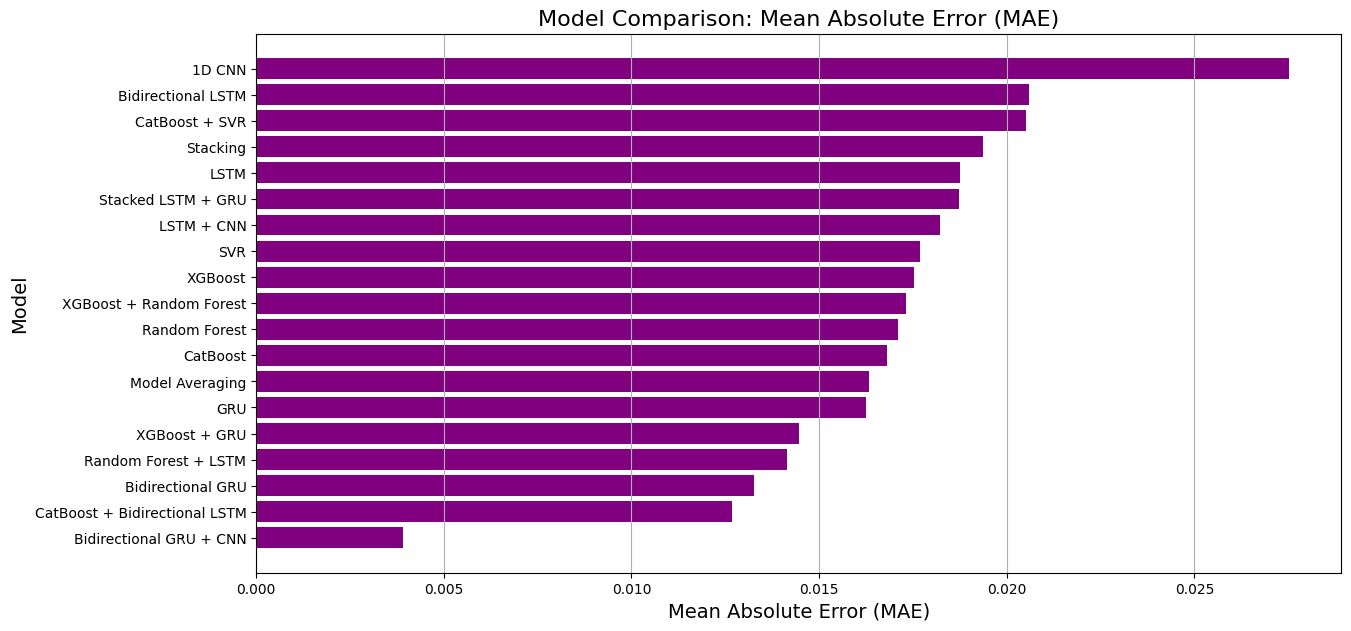

In [ ]:
# Visualize MAE
plot_metrics_comparison(results_df, "MAE", "Mean Absolute Error (MAE)", "purple")

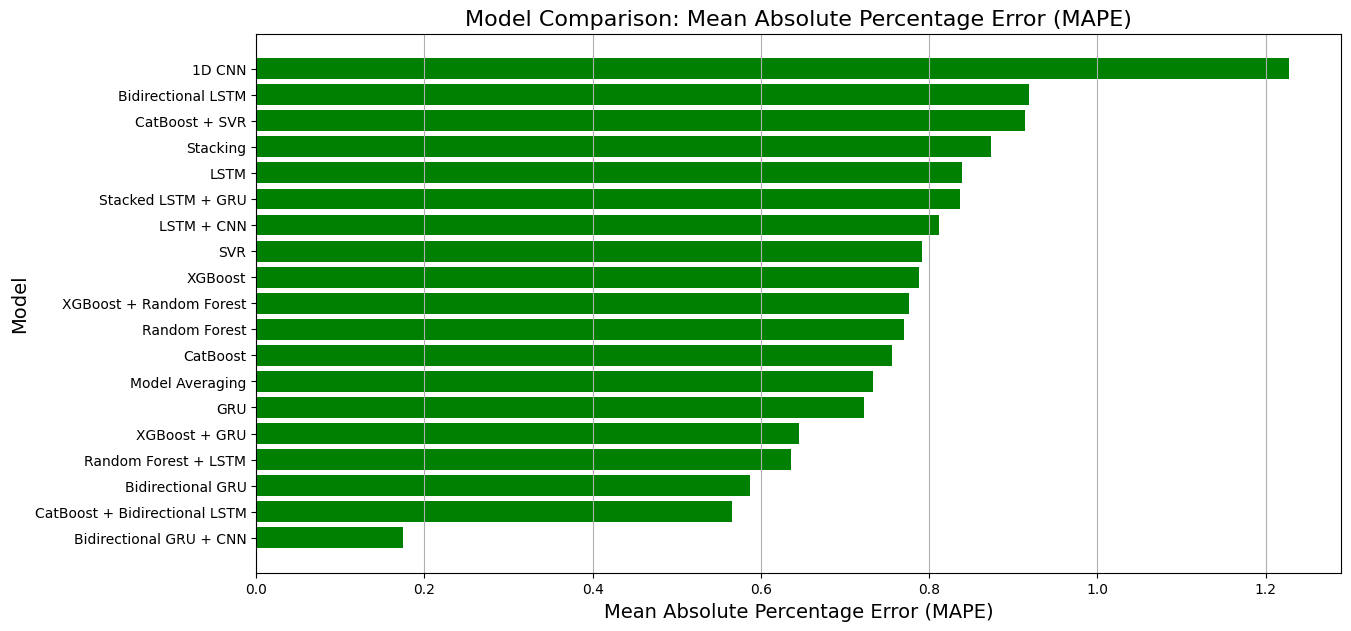

In [ ]:
# Visualize MAPE
plot_metrics_comparison(results_df, "MAPE (%)", "Mean Absolute Percentage Error (MAPE)", "green")

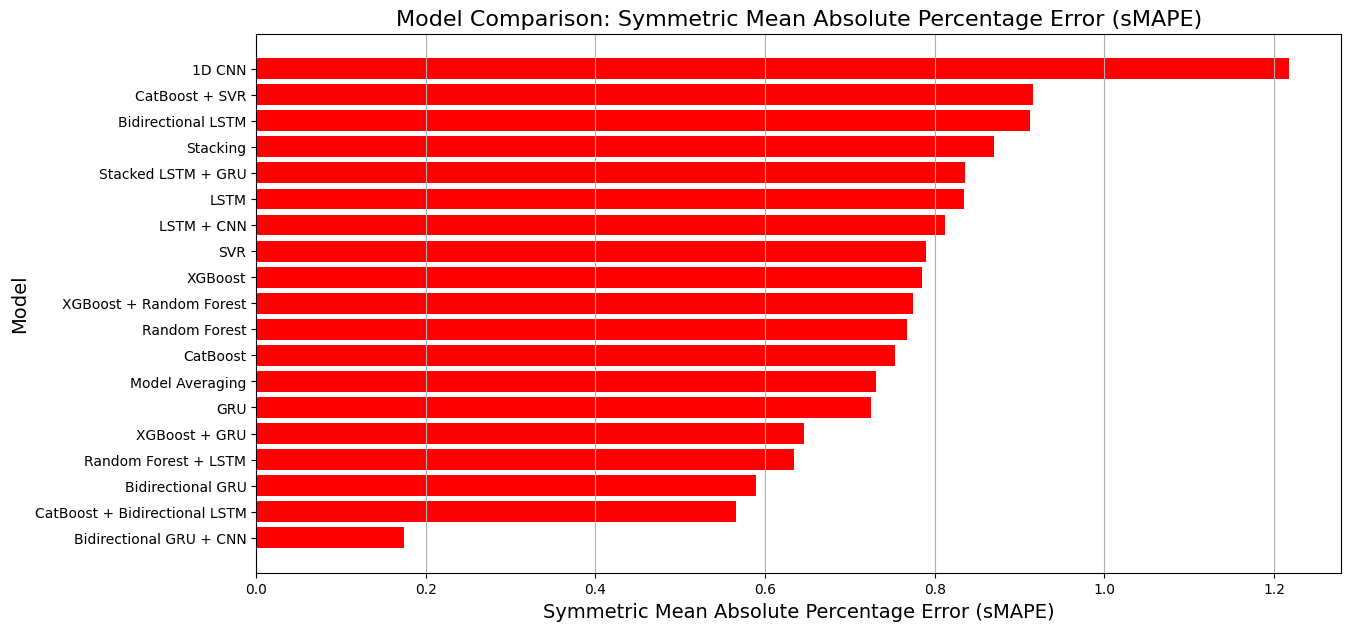

In [ ]:
# Visualize sMAPE
plot_metrics_comparison(results_df, "sMAPE (%)", "Symmetric Mean Absolute Percentage Error (sMAPE)", "red")

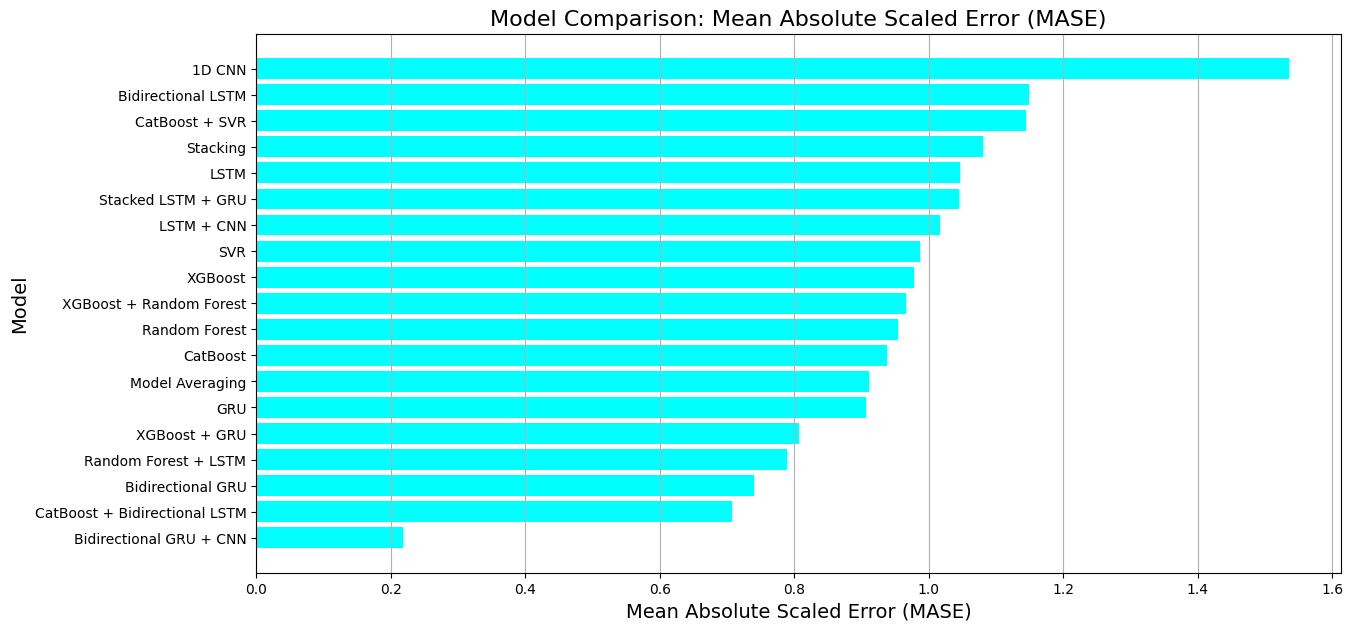

In [ ]:
# Visualize MASE
plot_metrics_comparison(results_df, "MASE", "Mean Absolute Scaled Error (MASE)", "cyan")

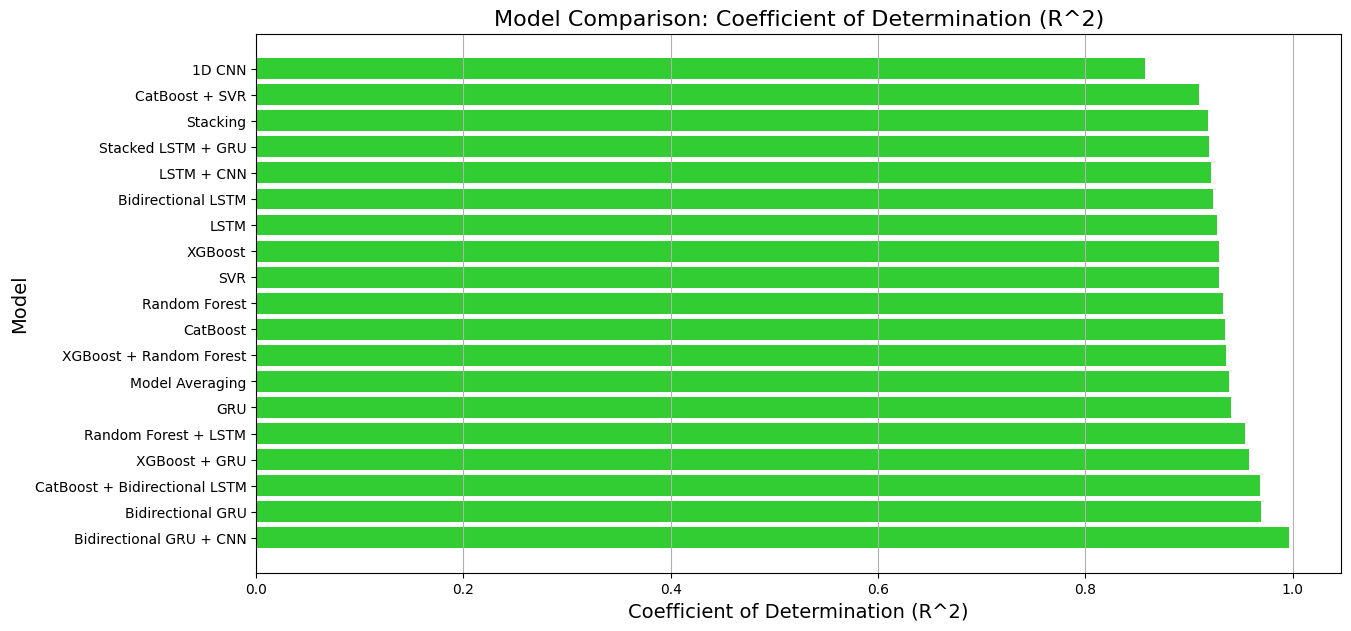

In [ ]:
# Visualize R^2
plot_metrics_comparison(results_df, "R^2", "Coefficient of Determination (R^2)", "limegreen")

In [ ]:
!pip install tabulate

In [ ]:
from tabulate import tabulate

# Convert results DataFrame to tabulate format
def display_metrics_table(results_df):
    # Convert DataFrame to list of lists for tabulate
    table_data = results_df.values.tolist()
    # Define headers
    headers = results_df.columns.tolist()
    # Print the table using tabulate
    print(tabulate(table_data, headers=headers, tablefmt="fancy_grid", floatfmt=".4f"))

# Display the table
print("Model Evaluation Metrics Summary:\n")
display_metrics_table(results_df)

Model Evaluation Metrics Summary:

╒═══════════════════════════════╤════════╤════════╤════════╤════════════╤═════════════╤════════╤════════╕
│ Model                         │    MSE │   RMSE │    MAE │   MAPE (%) │   sMAPE (%) │   MASE │    R^2 │
╞═══════════════════════════════╪════════╪════════╪════════╪════════════╪═════════════╪════════╪════════╡
│ Bidirectional GRU + CNN       │ 0.0000 │ 0.0051 │ 0.0039 │     0.1745 │      0.1745 │ 0.2187 │ 0.9969 │
├───────────────────────────────┼────────┼────────┼────────┼────────────┼─────────────┼────────┼────────┤
│ Bidirectional GRU             │ 0.0003 │ 0.0161 │ 0.0133 │     0.5870 │      0.5893 │ 0.7399 │ 0.9690 │
├───────────────────────────────┼────────┼────────┼────────┼────────────┼─────────────┼────────┼────────┤
│ CatBoost + Bidirectional LSTM │ 0.0003 │ 0.0163 │ 0.0127 │     0.5654 │      0.5656 │ 0.7071 │ 0.9681 │
├───────────────────────────────┼────────┼────────┼────────┼────────────┼─────────────┼────────┼────────┤
│ XGBoost +

In [ ]:
# Add Accuracy (%) calculation to metrics
def calculate_metrics_with_accuracy(y_true, y_pred, naive_forecast, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    # sMAPE
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100

    # MASE
    naive_mae = mean_absolute_error(y_true, naive_forecast)
    mase = mae / naive_mae if naive_mae != 0 else np.nan  # Avoid division by zero

    # Accuracy calculation
    mean_actual = np.mean(y_true)
    accuracy = 100 * (1 - (mae / mean_actual)) if mean_actual != 0 else np.nan  # Avoid division by zero

    return {
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        "sMAPE (%)": smape,
        "MASE": mase,
        "R^2": r2,
        "Accuracy (%)": accuracy
    }

# Initialize metrics_results with accuracy
metrics_results_with_accuracy = []

# Replace calculate_metrics with calculate_metrics_with_accuracy in all evaluations
for model_name, y_pred in zip(model_names, models_predictions):  # Assume model_names and models_predictions exist
    metrics_results_with_accuracy.append(
        calculate_metrics_with_accuracy(y_test.values, y_pred, naive_forecast, model_name)
    )

# Convert to DataFrame
results_df_with_accuracy = pd.DataFrame(metrics_results_with_accuracy)

# Display results with accuracy
print("Model Evaluation Metrics with Accuracy:\n")
display_metrics_table(results_df_with_accuracy)

Model Evaluation Metrics with Accuracy:

╒════════════════════╤════════╤════════╤════════╤════════════╤═════════════╤════════╤════════╤════════════════╕
│ Model              │    MSE │   RMSE │    MAE │   MAPE (%) │   sMAPE (%) │   MASE │    R^2 │   Accuracy (%) │
╞════════════════════╪════════╪════════╪════════╪════════════╪═════════════╪════════╪════════╪════════════════╡
│ Random Forest      │ 0.0006 │ 0.0237 │ 0.0171 │     0.7701 │      0.7674 │ 0.9544 │ 0.9326 │        99.2433 │
├────────────────────┼────────┼────────┼────────┼────────────┼─────────────┼────────┼────────┼────────────────┤
│ XGBoost            │ 0.0006 │ 0.0244 │ 0.0175 │     0.7874 │      0.7854 │ 0.9778 │ 0.9285 │        99.2248 │
├────────────────────┼────────┼────────┼────────┼────────────┼─────────────┼────────┼────────┼────────────────┤
│ CatBoost           │ 0.0005 │ 0.0233 │ 0.0168 │     0.7554 │      0.7529 │ 0.9382 │ 0.9349 │        99.2562 │
├────────────────────┼────────┼────────┼────────┼────────────┼─